In [57]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

In [58]:
# convert json to csv with mode vertex energies
t = 't=100'

cwd = Path.cwd()
json_path = cwd / 'WS2_Grating_Eamonn' / 'Results' / f'MoS₂, SiO₂, Si [5.22] {t}' / 'summary_v2.json'
print(json_path)

with open(json_path, 'r') as summary:
    data = json.load(summary)
    
periods = []
thicknesses = []
fillings = []
mean_energy = []
diff_energy = []


for key, value in data.items():
    #print(value)
    # Extract thickness (t) and period (Λ) from the key string
    key_parts = key.split()
    print(key_parts)
    
    
    thickness = float(key_parts[0].split('=')[1].replace('nm', ''))
    period = float(key_parts[1].split('=')[1].replace('nm', ''))
    filling = float(key_parts[2].split('=')[1])
    
    # Get the R2 value from fitting info
    keys = list(value['fitting info'].keys())
    
   

    temp_vertices:list = []
    temp_thickness:float = None
    temp_period:float = None

    temp_period = float(period)
    temp_thickness = float(thickness)
    temp_filling = float(filling)
    # ic(temp_filling)
    
    # Only consider entries with R2 > 0.6
    for i,key in enumerate(keys):
        R2 = value['fitting info'][key]['R2']
        if (abs(R2) > 0.6) and (R2 != 1.0):
            # Extract vertex value from fitting results
            vertex = value['fitting results']['vertices'][i]
            
            # Append data to lists
            temp_vertices.append([key,vertex])
            #print([key,vertex])
            
    if len(temp_vertices) == 2:
        vtc1 = temp_vertices[0]
        vtc2 = temp_vertices[1]
            
        vtcs: list = [float(vtc1[1]), float(vtc2[1])]
        # ic(vtcs, temp_filling, temp_period, temp_thickness)
        mean_energy.append(np.mean(vtcs))
        # print(temp_vertices, np.diff(vtcs))
        diff_energy.append(abs(float(np.diff(vtcs)[0])))
        print(vtcs, np.mean(vtcs), np.diff(vtcs)[0])
        
        periods.append(temp_period)
        thicknesses.append(temp_thickness)
        fillings.append(temp_filling)
        
        
df_filtered = pd.DataFrame(columns=['period', 'thickness', 'filling', 'mean_energy', 'diff_energy'])
df_filtered['period'] = periods
df_filtered['thickness'] = thicknesses
df_filtered['filling'] = fillings
df_filtered['mean_energy'] = mean_energy
df_filtered['diff_energy'] = diff_energy

df_filtered.head()
# df_filtered.describe()





/Users/williamhampshire/Desktop/pycharm/research_project/WS2_Grating_Eamonn/Results/MoS₂, SiO₂, Si [5.22] t=100/summary_v2.json
['t=100.0nm', 'Λ=250nm', 'FF=0.80', 'N=125']
[1.583732418382172, 1.4020653294756742] 1.492898873928923 -0.18166708890649774
['t=100.0nm', 'Λ=300nm', 'FF=0.70', 'N=125']
[1.5401690951158953, 1.3021264438865185] 1.421147769501207 -0.23804265122937673
['t=100.0nm', 'Λ=300nm', 'FF=0.80', 'N=125']
[1.424658185657156, 1.2630561190544585] 1.3438571523558074 -0.1616020666026976


,period,thickness,filling,mean_energy,diff_energy
0,250.0,100.0,0.8,1.492899,0.181667
1,300.0,100.0,0.7,1.421148,0.238043
2,300.0,100.0,0.8,1.343857,0.161602


In [59]:
results_dir = cwd / 'mode_fitting' / 'manual'
results_dir.mkdir(exist_ok=True)

df_filtered.to_csv(results_dir/f'{t}.csv', sep=',',header=True)

Read in and plot

In [60]:
files = os.listdir(results_dir)

df = pd.DataFrame(columns=['period', 'thickness', 'filling', 'mean_energy', 'diff_energy'])
for file in files:
    if '.csv' in file:
        name = file.rstrip('.csv')
        data_temp = pd.read_csv(results_dir/file, index_col=0)
        df = pd.concat([df, data_temp], axis=0)
        
print(df)

   period  thickness  filling  mean_energy  diff_energy
0   250.0       60.0      0.8     1.617709     0.141603
1   300.0       60.0      0.8     1.492836     0.166733
2   350.0       60.0      0.7     1.446480     0.223953
3   350.0       60.0      0.8     1.380588     0.158787
4   400.0       60.0      0.7     1.347685     0.213422
0   250.0      100.0      0.8     1.492899     0.181667
1   300.0      100.0      0.7     1.421148     0.238043
2   300.0      100.0      0.8     1.343857     0.161602
0   300.0       40.0      0.8     1.617251     0.141576
1   350.0       40.0      0.7     1.571161     0.196535
2   350.0       40.0      0.8     1.514526     0.155455
3   400.0       40.0      0.7     1.481439     0.212122
4   400.0       40.0      0.8     1.417806     0.144552
5   450.0       40.0      0.7     1.390951     0.181890
6   450.0       40.0      0.8     1.332539     0.130758
0   250.0       80.0      0.8     1.546709     0.164151
1   300.0       80.0      0.7     1.482501     0

/var/folders/pk/mrkz02nn7qd5bc8rndd2bd8c0000gn/T/ipykernel_11949/257647005.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, data_temp], axis=0)


<Figure size 1500x1000 with 0 Axes>

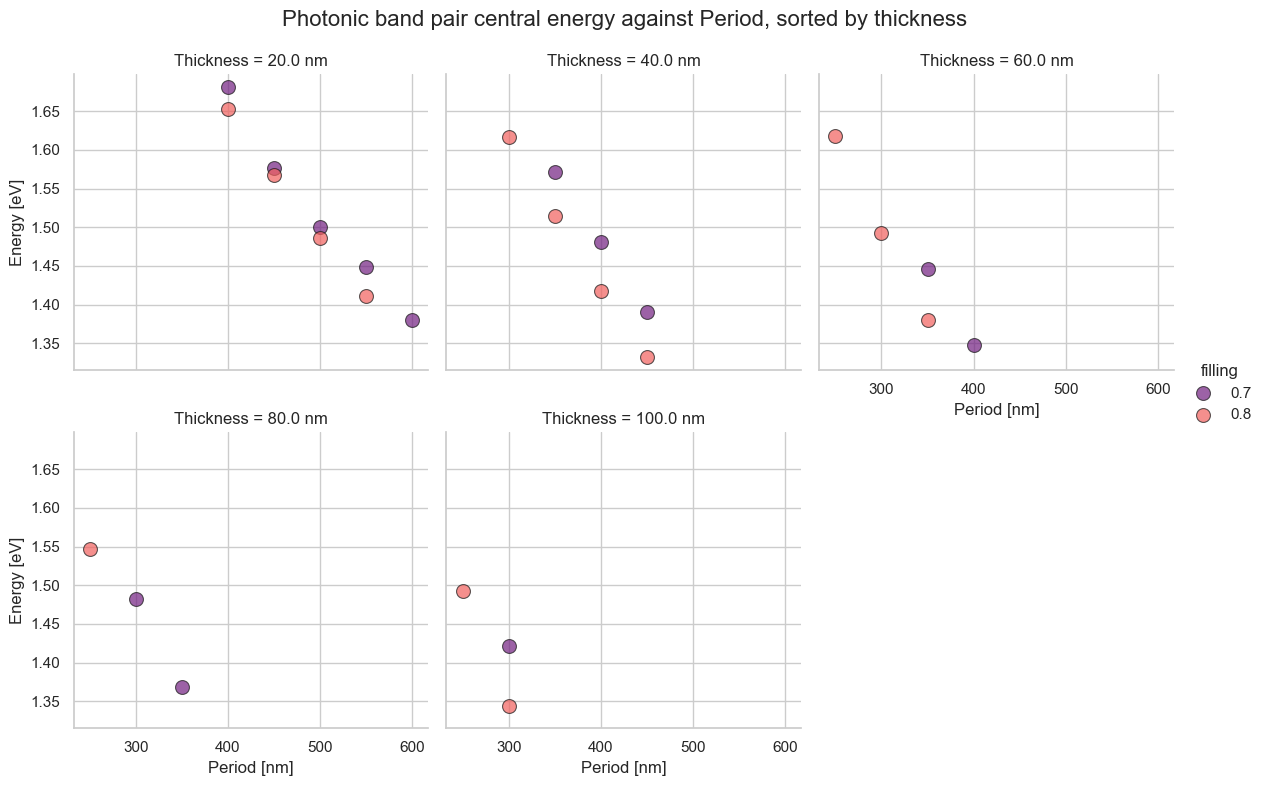

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the seaborn style
sns.set_theme(style="whitegrid")

# Create the figure for the 2D plots (Energy vs Period, with Thickness as separate plots)
fig1 = plt.figure(figsize=(15, 10))
g1 = sns.FacetGrid(
    data=df,
    col="thickness", 
    col_wrap=3, 
    height=4, 
    hue="filling", 
    palette="magma"
)
g1.map_dataframe(
    sns.scatterplot, 
    x="period", 
    y="mean_energy", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
p_lab='Period [nm]'
t_lab='Thickness [nm]'
e_lab='Energy [eV]'
g1.set_axis_labels(p_lab, e_lab)
g1.set_titles(col_template="Thickness = {col_name} nm")
g1.add_legend()

# Display the Energy vs Period plot grid
plt.subplots_adjust(top=0.9)
g1.fig.suptitle('Photonic band pair central energy against Period, sorted by thickness', fontsize=16)

savepath = cwd / 'mode_fitting_viz'
savepath.mkdir(exist_ok=True)
plt.savefig(savepath/'central_energy_period_refined.png', dpi=300)

plt.show()